#### Decision Tree

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [24]:
from sklearn.datasets import load_iris
iris=load_iris()


In [ ]:
## Feature Extraction
X=iris['data']
y=iris['target']
X=pd.DataFrame(X,columns=['S_Length','S_Width','P_length','P_width'])

In [22]:
## Train test Split
from sklearn.model_selection import train_test_split 
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.30)


In [23]:
## Note- Decision Tree do not require any type of standardization or normalization
## Apply Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
treeClassifier=DecisionTreeClassifier()
treeClassifier.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


[Text(0.5416666666666666, 0.9285714285714286, 'x[3] <= 0.8\ngini = 0.663\nsamples = 105\nvalue = [30, 37, 38]'),
 Text(0.4583333333333333, 0.7857142857142857, 'gini = 0.0\nsamples = 30\nvalue = [30, 0, 0]'),
 Text(0.5, 0.8571428571428572, 'True  '),
 Text(0.625, 0.7857142857142857, 'x[3] <= 1.75\ngini = 0.5\nsamples = 75\nvalue = [0, 37, 38]'),
 Text(0.5833333333333333, 0.8571428571428572, '  False'),
 Text(0.4166666666666667, 0.6428571428571429, 'x[2] <= 5.35\ngini = 0.18\nsamples = 40\nvalue = [0, 36, 4]'),
 Text(0.3333333333333333, 0.5, 'x[0] <= 4.95\ngini = 0.1\nsamples = 38\nvalue = [0, 36, 2]'),
 Text(0.16666666666666666, 0.35714285714285715, 'x[1] <= 2.45\ngini = 0.5\nsamples = 2\nvalue = [0, 1, 1]'),
 Text(0.08333333333333333, 0.21428571428571427, 'gini = 0.0\nsamples = 1\nvalue = [0, 1, 0]'),
 Text(0.25, 0.21428571428571427, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.5, 0.35714285714285715, 'x[1] <= 2.25\ngini = 0.054\nsamples = 36\nvalue = [0, 35, 1]'),
 Text(0.41

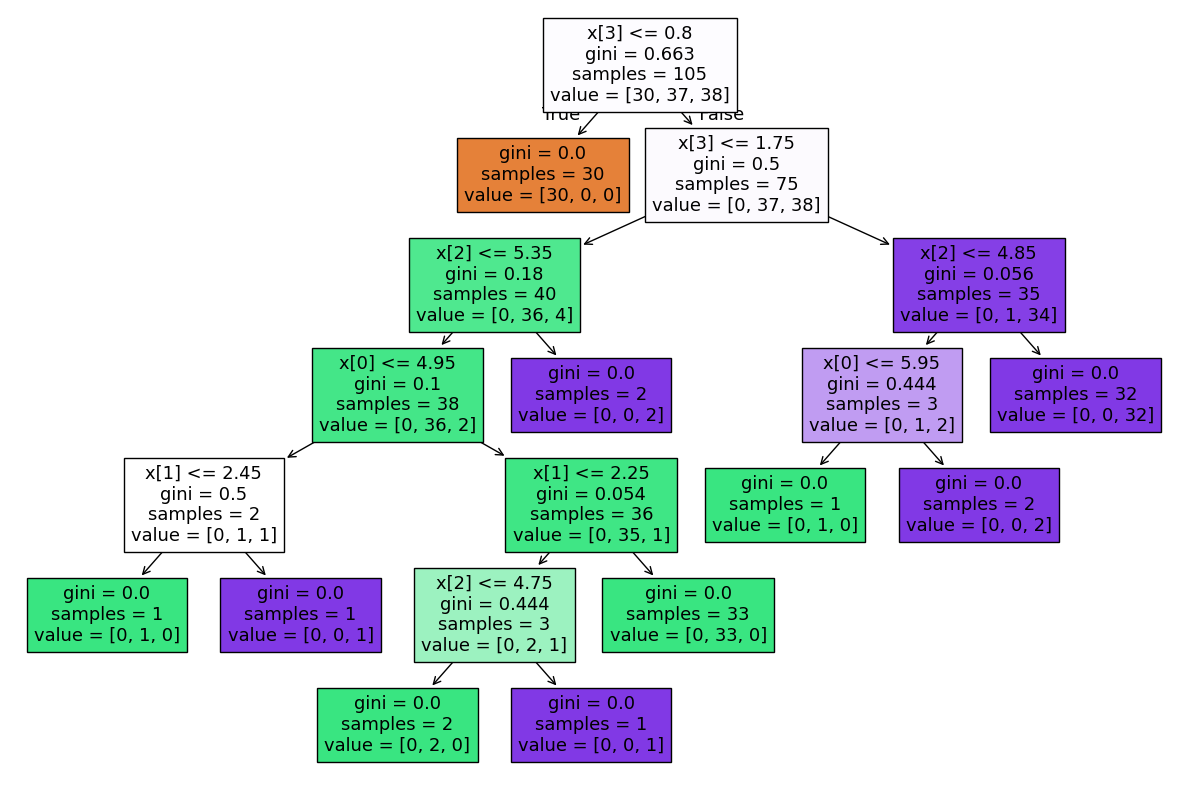

In [27]:
## visualize Tree
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(treeClassifier,filled=True)

In [30]:
y_pred=treeClassifier.predict(X_test)
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[20  0  0]
 [ 0 13  0]
 [ 0  1 11]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       0.93      1.00      0.96        13
           2       1.00      0.92      0.96        12

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45




#### PostPruning

In [ ]:

## Note- Decision Tree do not require any type of standardization or normalization
## Apply Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
treeClassifier=DecisionTreeClassifier(max_depth=2)
treeClassifier.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [35]:
y_pred=treeClassifier.predict(X_test)
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[20  0  0]
 [ 0 13  0]
 [ 0  1 11]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       0.93      1.00      0.96        13
           2       1.00      0.92      0.96        12

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45



#### PrePruning

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder,OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
pipeline=Pipeline([
    ('dt',DecisionTreeClassifier())
])

param_grid = {
    'dt__criterion': ['gini', 'entropy', 'log_loss'],
    'dt__splitter': ['best', 'random'],
    'dt__max_depth': [5,3,4,7,2,9] ,
    'dt__min_samples_split': [200,170,40,30,20,22,25] ,
    'dt__min_weight_fraction_leaf': [0.1,0.01,0.05],
    'dt__max_features': ['sqrt', 'log2',2,3]


}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=3
)

grid.fit(X_train, y_train)

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'dt__criterion': ['gini', 'entropy', ...], 'dt__max_depth': [5, 3, ...], 'dt__max_features': ['sqrt', 'log2', ...], 'dt__min_samples_split': [200, 170, ...], ...}"
,scoring,'neg_mean_squared_error'
,n_jobs,3
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [41]:
grid.best_params_

{'dt__criterion': 'entropy',
 'dt__max_depth': 5,
 'dt__max_features': 3,
 'dt__min_samples_split': 30,
 'dt__min_weight_fraction_leaf': 0.01,
 'dt__splitter': 'random'}

In [42]:
y_pred=grid.predict(X_test)
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[20  0  0]
 [ 0 13  0]
 [ 0  1 11]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       0.93      1.00      0.96        13
           2       1.00      0.92      0.96        12

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45

